## Contexte :
R-Ball Factory développe sa nouvelle gamme **RB2** (ballons de rugby).  
Objectif du TP : **décrire** des échantillons expérimentaux et **modéliser** leurs distributions, les incertitudes de mesures liés aux tests, puis **comparer** des matériaux à l'aide de tests statistiques.


## Scénario :
Les experts chimistes de l'entreprise proposent deux adhésifs différents :
  - Matériau A : `Adhesyl` (adhésif à base caoutchouc) matériau historique de l'entreprise.
  - Matériau B : `GripTex` (ex : adhésif polymère renforcé) nouveau procédé couteux mais plus écologique.
  
Afin de comparer ces deux matériaux, les experts réalisent un deuxième test après celui du test d’adhérence pour le Grip (TP1) :
- un test de résistance à la rupture.

En tant que statisticien, vous souhaitez contribuer à cette étude en mobilisant vos compétences.    
Votre objectif : analyser les résultats expérimentaux afin de déterminer quel matériau présente les meilleures performances.

## Descritpion du test **Rupture** :
*Obejctif* : On utilise une machine de traction qui étire un échantillon du matériau du ballon jusqu'à sa rupture. Nous chercons à modéliser la durée de vie et la fiabilité des matériaux.   
- Préparation : Un échantillon du matériau (par exemple, le caoutchouc synthétique externe) est découpé dans une forme standardisée (souvent en forme d'haltère).   
- Mesure : L'échantillon est placé entre deux pinces de la machine de traction. La machine commence à l'étirer à une vitesse constante, tout en mesurant la force appliquée et l'allongement de l'échantillon.

*Résultat* : On enregistre la force maximale (fmax, en Newtons, N) que l'échantillon a pu supporter juste avant de se rompre.

## Étapes du TP :
1. Chargement de données.
2. Exploration descriptive (descripteur, histogrammes, QQ-plots...).
3. Définir la loi de probabilité associée.
4. Comparaison des deux matériaux (échantillons):  
  4.1 Comparaison des moyennes.   
  4.2 Comparaison du 50 et 70ème percentile.
5. Interprétation et conclusion.

**Packages requis :**
`numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `statsmodels`.


### Création des données

In [ ]:
#un format csv
from io import StringIO
rupt = StringIO("""
Matériau,Rupture
Adhesyl,1287.206702619965
Adhesyl,501.3478916322336
Adhesyl,894.1920781492026
Adhesyl,489.68364518444184
Adhesyl,713.625272311777
Adhesyl,1504.336374458278
Adhesyl,403.71753995287264
Adhesyl,271.8837767454115
Adhesyl,710.4825104857277
Adhesyl,821.9490566633408
Adhesyl,712.7511385937727
Adhesyl,1025.7068849543068
Adhesyl,600.3532880507112
Adhesyl,258.056826287999
Adhesyl,878.5634715184495
Adhesyl,2013.3525362225416
Adhesyl,1023.3362398788956
Adhesyl,743.7046507621665
Adhesyl,1042.0320026892266
Adhesyl,357.14801046040986
Adhesyl,1595.53204366162
Adhesyl,1069.201146648408
Adhesyl,603.009025064242
Adhesyl,403.3543368113508
Adhesyl,1253.173130403191
Adhesyl,773.4373026363508
Adhesyl,1057.3517004271216
Adhesyl,438.3170783668646
Adhesyl,1497.6386294569431
Adhesyl,2211.7349411216865
Adhesyl,519.9179945547827
Adhesyl,1631.8099161270547
Adhesyl,819.0537523290246
Adhesyl,69.5867497304008
Adhesyl,273.07305252348345
Adhesyl,478.6166868571665
Adhesyl,628.5008115335793
Adhesyl,1482.8948181281692
Adhesyl,1592.7693452695776
Adhesyl,1485.3477573451971
Adhesyl,458.17071614185187
Adhesyl,2173.451608305146
Adhesyl,480.59572867038844
Adhesyl,711.7562822918466
Adhesyl,184.04980487842508
Adhesyl,397.1744722403166
Adhesyl,1092.347753694799
Adhesyl,981.5655488818796
Adhesyl,1081.6531763881342
Adhesyl,728.8626850264368
Adhesyl,314.523717098044
Adhesyl,739.8510696965236
Adhesyl,1769.026927835635
Adhesyl,735.3321162326502
Adhesyl,962.3228842560286
Adhesyl,1169.0117584902578
Adhesyl,55.609065436297
Adhesyl,354.82153982680586
Adhesyl,2031.8883350662613
GripTex,948.2215051001992
GripTex,443.6547061922595
GripTex,926.8138138573595
GripTex,1289.390661126949
GripTex,867.6268161381507
GripTex,1190.050490528135
GripTex,1000.2715589445024
GripTex,973.7647774311394
GripTex,1330.7483672541493
GripTex,1295.4085128835404
GripTex,809.1392141696122
GripTex,1071.035574777531
GripTex,1330.833953072192
GripTex,1180.951037153488
GripTex,1110.8212241421277
GripTex,595.9297586425413
GripTex,850.6994917962753
GripTex,1086.9432929100892
GripTex,886.9190850235716
GripTex,1655.2982887168475
GripTex,557.3721397606811
GripTex,1191.0082728727014
GripTex,1127.0222354101716
GripTex,673.4054118385891
GripTex,1240.0037020443942
GripTex,956.5692736048323
GripTex,987.124063996074
GripTex,1172.3765341422247
GripTex,960.8008823377488
GripTex,1046.3347328216328
GripTex,1317.8297882043707
GripTex,511.58836495541783
GripTex,1100.4733372455728
GripTex,1035.2653203334553
GripTex,966.2324820956158
GripTex,1110.4954702478522
GripTex,963.6818643345825
GripTex,945.2632250164381
GripTex,1145.5323010198297
GripTex,761.6162208953796
GripTex,1609.4317625743856
GripTex,1233.811107983901
GripTex,1549.3274055508234
GripTex,1278.8315298435652
GripTex,942.6163599279566
GripTex,548.7398914634932
GripTex,1451.5505779845644
GripTex,978.0136863690101
GripTex,1243.320507370145
GripTex,1182.8324133742678
GripTex,1355.398711006071
GripTex,933.6132304600812
GripTex,1737.1030004395427
GripTex,1111.386233461186
GripTex,798.55412295634
GripTex,951.5859103892816
GripTex,953.9050410919913
GripTex,942.0629471213942
GripTex,830.4615340021095
""")

# 1. Importation des libraries et chargement des données



In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
df_rupt = pd.read_csv(rupt)
rupt1 = df_rupt[df_rupt['Matériau'] == 'Adhesyl']['Rupture']
rupt2 = df_rupt[df_rupt['Matériau'] == 'GripTex']['Rupture']

## 2. Exploration descriptive
Représentez les échantillons à l'aide des graphiques et des indicateurs statistiques que vous jugez les plus pertinents.

In [ ]:
#Pour le matériau1(rupt1)
print("Pour le matériau1(rupt1)")
print(rupt1.describe())
print("Pour le matériau2(rupt2)")
print(rupt2.describe())

Pour le matériau1(rupt1)
count      59.000000
mean      890.843480
std       535.093402
min        55.609065
25%       479.606208
50%       743.704651
75%      1130.679756
max      2211.734941
Name: Rupture, dtype: float64
Pour le matériau2(rupt2)
count      59.000000
mean     1055.034978
std       271.420591
min       443.654706
25%       937.838089
50%      1035.265320
75%      1212.409690
max      1737.103000
Name: Rupture, dtype: float64


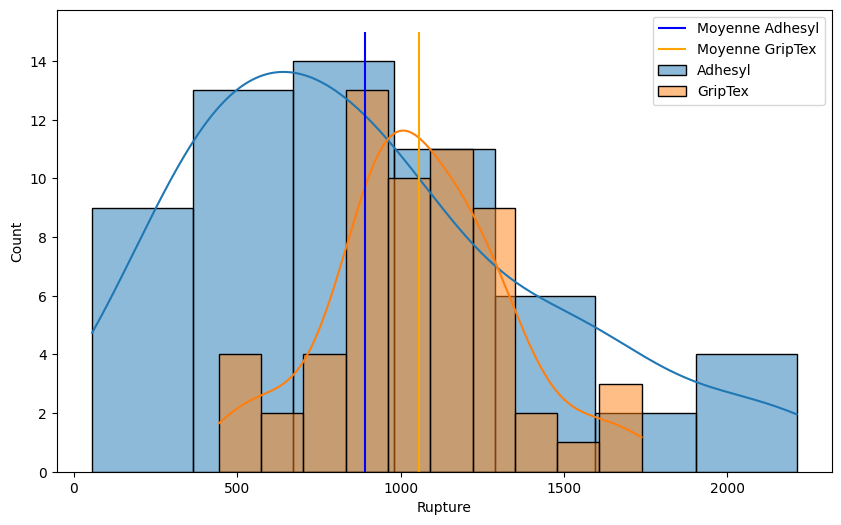

In [ ]:
#tracé de l'histogramme
plt.figure(figsize=(10, 6))
sns.histplot(rupt1, kde=True,label = "Adhesyl")
sns.histplot(rupt2, kde=True,label = "GripTex")
#kde : approximation lisse de la distribution empirique.
plt.vlines(rupt1.mean(), 0, 15, color = 'blue', label = 'Moyenne Adhesyl')
plt.vlines(rupt2.mean(), 0,15, color = 'orange',label = 'Moyenne GripTex')
plt.legend()
plt.show()


<Figure size 1000x600 with 0 Axes>

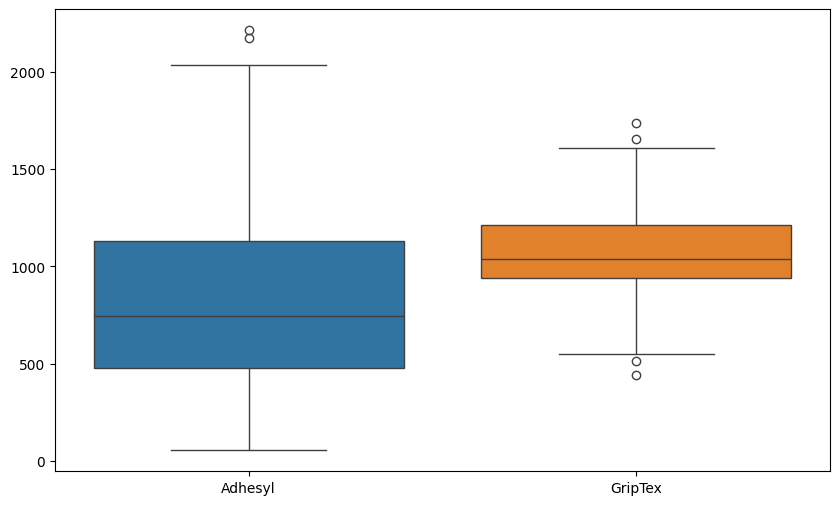

In [ ]:
#tracé du boxplot
plt.figure(figsize=(10, 6))
df = pd.DataFrame({'Adhesyl': rupt1, 'GripTex': rupt2})
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.show()


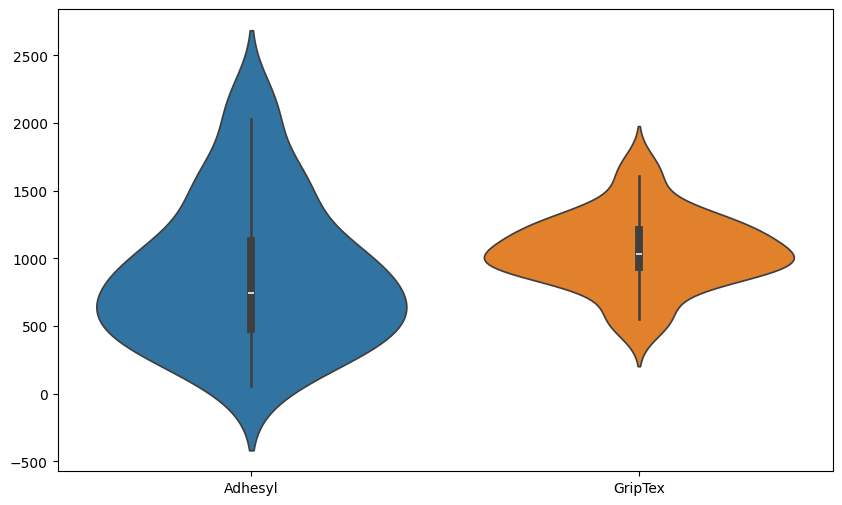

In [ ]:
#tracé du violinplot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df)
plt.show()

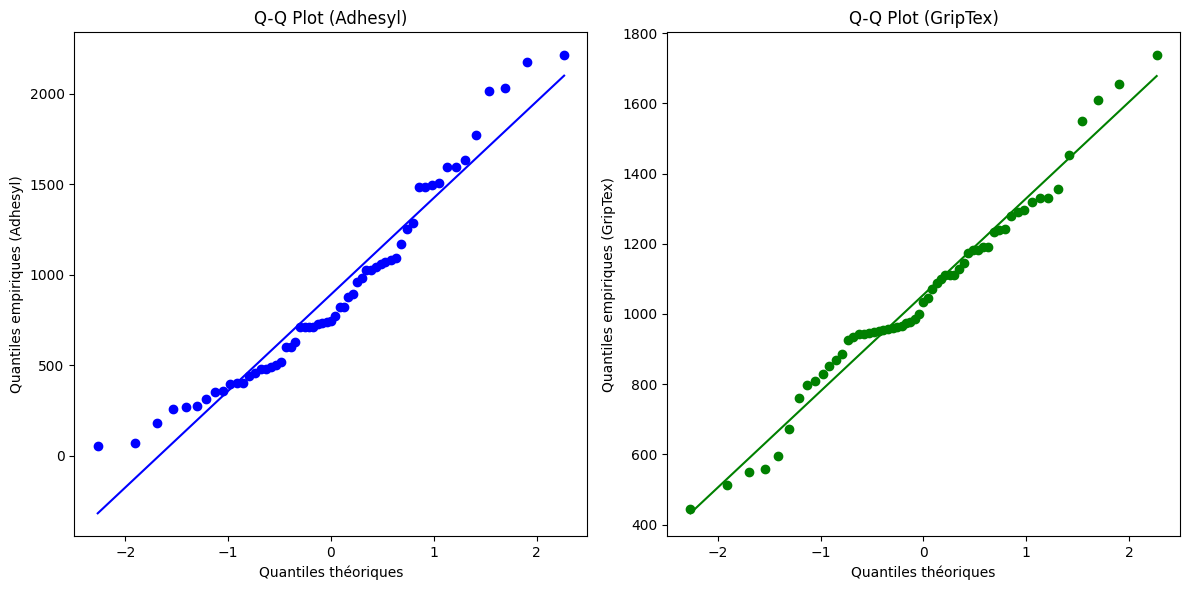

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

color_adhesyl = 'blue'
color_griptex = 'green'

# Plot for rupt1 (Adhesyl)
stats.probplot(rupt1, dist="norm", plot=axes[0])
axes[0].get_lines()[0].set_color(color_adhesyl) #
axes[0].get_lines()[1].set_color(color_adhesyl)
axes[0].set_title('Q-Q Plot (Adhesyl)')
axes[0].set_xlabel('Quantiles théoriques')
axes[0].set_ylabel('Quantiles empiriques (Adhesyl)')

# Plot for rupt2 (GripTex)
stats.probplot(rupt2, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color(color_griptex)
axes[1].get_lines()[1].set_color(color_griptex)
axes[1].set_title('Q-Q Plot (GripTex)')
axes[1].set_xlabel('Quantiles théoriques')
axes[1].set_ylabel('Quantiles empiriques (GripTex)')

plt.tight_layout()
plt.show()

Quels sont les remarques que vous pouvez faire avec les mesures de tendances centrales, celles de dispertions et de formes ?

### Écart-type
L’écart-type obtenu pour le matériau **Adhésyl** est de **535**, contre **271** pour **Griptex**.  
Cela indique que les valeurs autour de la moyenne sont **plus dispersées pour Adhésyl**, tandis que **Griptex présente une variabilité plus faible**, traduisant un comportement plus homogène.

### Moyenne et médiane
Pour le matériau **Griptex**, la **moyenne et la médiane sont très proches**, contrairement à **Adhésyl**.  
Cette proximité suggère une **meilleure répartition des données** pour Griptex, avec une distribution plus symétrique et moins influencée par des valeurs extrêmes.

##Histogrammes (avec KDE)

###Adhesyl :
L'histogramme montre une distribution asymétrique (skewed) vers la droite, avec une longue queue. La moyenne est tirée vers les valeurs élevées par quelques points de données extrêmes. La densité de probabilité (KDE) est plus large, indiquant une plus grande variabilité des résistances à la rupture pour ce matériau.

###GripTex  :
L'histogramme du GripTex apparaît plus symétrique et plus concentré autour de sa moyenne . La distribution est plus étroite, ce qui suggère une plus grande cohérence et une moindre variabilité des résistances à la rupture comparé à l'Adhesyl. La plupart des valeurs sont regroupées autour d'une résistance plus élevée que celles de l'Adhesyl.

## Boxplots

###Adhesyl :
Le boxplot de l'Adhesyl est plus étiré, avec une boîte plus grande et des moustaches plus longues, ce qui confirme une plus grande dispersion des données. La médiane  est relativement basse, et il y a plusieurs points identifiés comme des valeurs aberrantes vers le haut, expliquant l'asymétrie vue dans l'histogramme.

###GripTex :
Le boxplot du GripTex est plus compact. Sa médiane est nettement plus élevée que celle de l'Adhesyl, indiquant que la moitié des échantillons de GripTex ont une résistance supérieure à celle de la plupart des échantillons d'Adhesyl. La boîte et les moustaches sont plus courtes, montrant une variabilité beaucoup plus faible. Il y a aussi quelques outliers, mais moins prononcés que pour l'Adhesyl.

##Violinplots

###Adhesyl :
Le violinplot de l'Adhesyl montre une forme large et asymétrique, reflétant la distribution étalée et la présence de valeurs plus élevées. La zone dense est concentrée autour des valeurs plus basses, puis s'amincit progressivement vers des valeurs plus élevées, ce qui corrobore l'asymétrie positive.

###GripTex :
Le violinplot du GripTex est plus étroit et plus cylindrique, avec une densité concentrée autour de la médiane plus élevée. Sa forme plus symétrique et compacte confirme une distribution plus homogène et des performances plus stables pour ce matériau.


# 3. Définir la loi de probabilité associée.   
Indice : Normal (test de normalité) ou autre (test de conformité)

In [ ]:
#Test de shapiro-wilk
print("Test Shapiro-Wilk")
print("Pour le matériau1(rupt1)")
stat, p = stats.shapiro(rupt1)
print("stats = %.3f, p = %.3f" % (stat,p))

print("Pour le matériau2(rupt2)")
stat,p = stats.shapiro(rupt2)
print("stats = %.3f, p = %.3f" % (stat,p))

Test Shapiro-Wilk
Pour le matériau1(rupt1)
stats = 0.941, p = 0.007
Pour le matériau2(rupt2)
stats = 0.978, p = 0.379


In [ ]:
#Test D’Agostino-Pearson
print("Test D’Agostino-Pearson")
print("Pour le matériau1(rupt1)")
stat, p = stats.normaltest(rupt1)
print("stats = %.3f, p = %.3f" % (stat,p))

print("Pour le matériau2(rupt2)")
stat,p = stats.normaltest(rupt2)
print("stats = %.3f, p = %.3f" % (stat,p))

Test D’Agostino-Pearson
Pour le matériau1(rupt1)
stats = 5.489, p = 0.064
Pour le matériau2(rupt2)
stats = 0.832, p = 0.660


In [ ]:
#Test de Kilmogorov-Smirnov
print("Test de Kilmogorov-Smirnov")
mean, std = rupt1.mean(), rupt1.std()
stat, p = stats.ks_1samp(rupt1, lambda x: stats.norm.cdf(x, loc=mean, scale=std))
print("stats = %.3f, p = %.3f" % (stat,p))

mean, std =rupt2.mean(),rupt2.std()
stat, p = stats.ks_1samp(rupt2, lambda x: stats.norm.cdf(x, loc=mean, scale=std))
print("stats = %.3f, p = %.3f" % (stat,p))

Test de Kilmogorov-Smirnov
stats = 0.117, p = 0.368
stats = 0.098, p = 0.588


##Interprétations:
### Test de Pearson et de Kilmogorov-Smirnov
Le test de Pearson et de kilmogorov-Smirnov ont une p_value>0.05 dont les deux matériaux suivent une loi normale.

###Test de shapiro

Nous avons obtenu une p_value de 0.007 pour Adhesyl ce qui veut dire que ce matériau ne suit pas une loi normale comparé à celui de Griptex.

# 4. Comparaison des deux matériaux (échantillons):  
A réalisé au risque de 5%.

##  4.1 Comparaison des moyennes.   
Info, on connait la dispertion du test 5N.


In [ ]:
#Test Z car on connait sigma
print("Test Z car on connait sigma")
sigma = 5
n1, n2 = len(rupt1), len(rupt2)
mean1, mean2 = np.mean(rupt1), np.mean(rupt2)
z = (mean1 - mean2) / np.sqrt(sigma/n1 + sigma/n2)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Test Z (σ²={sigma}): Z = {z:.3f}, p-value = {p_value:.3f} → {'produits similaires' if p_value > 0.05 else 'produits différents'}")


Test Z car on connait sigma
Test Z (σ²=5): Z = -398.820, p-value = 0.000 → produits différents


##Interprétation:
Nous avons obtenu une p_value < 0.05, ce qui montre que les matériaux sont différents.

## 4.2 Comparaison pour le 50 et 70ème percentile.

In [ ]:
print("Comparaison des percentiles:")

# Calcul du 50ème percentile (médiane)
median_rupt1 = np.percentile(rupt1, 50)
median_rupt2 = np.percentile(rupt2, 50)
print(f"  50ème percentile (médiane) - Adhesyl: {median_rupt1:.3f}")
print(f"  50ème percentile (médiane) - GripTex: {median_rupt2:.3f}")

# Calcul du 70ème percentile
percentile_70_rupt1 = np.percentile(rupt1, 70)
percentile_70_rupt2 = np.percentile(rupt2, 70)
print(f"  70ème percentile - Adhesyl: {percentile_70_rupt1:.3f}")
print(f"  70ème percentile - GripTex: {percentile_70_rupt2:.3f}")

Comparaison des percentiles:
  50ème percentile (médiane) - Adhesyl: 743.705
  50ème percentile (médiane) - GripTex: 1035.265
  70ème percentile - Adhesyl: 1064.461
  70ème percentile - GripTex: 1182.080


## 4.3  [Test Mann-Whitney](https://numiqo.fr/tutorial/mann-whitney-u-test)

In [ ]:
stat, p = stats.mannwhitneyu(rupt1, rupt2)
print("stats = %.3f, p = %.3f" % (stat,p))

stats = 1203.000, p = 0.004



# 5. Interprétation et conclusion.
Quel est le meilleur matériaux pourquoi ?


### Comparaison des matériaux

Le test de **Mann–Whitney U** conduit à une **p-value de 0,004**, inférieure au seuil de signification alpha = 0,05\. L’hypothèse nulle \(H_0\) est donc rejetée, ce qui met en évidence une **différence statistiquement significative** entre les deux matériaux.

Par ailleurs, la comparaison des indicateurs de tendance centrale et de position montre que la **médiane du matériau Griptex est supérieure à celle de l’Adhesyl**. Cette supériorité se confirme également au **70ᵉ percentile**, indiquant de meilleures performances pour les niveaux élevés.

**En conclusion**, le matériau **Griptex** apparaît comme le meilleur, car il présente des **médianes et des 70ᵉ percentiles plus élevés**, traduisant des performances globalement supérieures.
